In [1]:
!pip install staticvectors scikit-learn pandas matplotlib adjustText

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from staticvectors import StaticVectors
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from adjustText import adjust_text

/workspaces/Decisions-by-Design_v1/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
model = StaticVectors("neuml/word2vec/model.sqlite")

In [4]:
words = [
    "king", "queen", "prince", "princess", "man", "woman",
    "doctor", "nurse", "teacher", "professor",
    "dog", "cat", "horse", "cow", "lion", "tiger",
    "apple", "banana", "orange", "grape",
    "car", "truck", "train", "airplane",
    "math", "algebra", "geometry", "calculus", "statistics"
]

vectors = model.embeddings(words)
vectors.shape

(29, 300)

### Principal Component Analysis

In [5]:
pca = PCA(n_components=2)
pca_points = pca.fit_transform(vectors)

pca_df = pd.DataFrame({
    "word": words,
    "x": pca_points[:, 0],
    "y": pca_points[:, 1]
})

pca.explained_variance_ratio_

array([0.13452135, 0.10697668], dtype=float32)

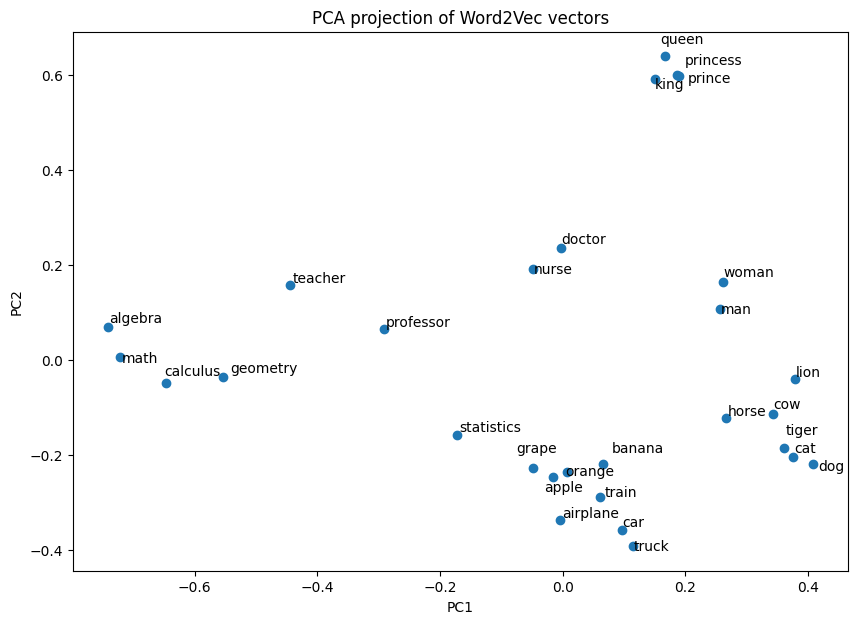

In [6]:
plt.figure(figsize=(10, 7))
plt.scatter(pca_df["x"], pca_df["y"])

texts = []
for _, row in pca_df.iterrows():
    texts.append(plt.text(row["x"], row["y"], row["word"]))

adjust_text(texts)

plt.title("PCA projection of Word2Vec vectors")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

### t-SNE Dimensionality Reduction

In [7]:
tsne = TSNE(
    n_components=2,
    perplexity=5,
    learning_rate="auto",
    init="pca",
    random_state=42
)

tsne_points = tsne.fit_transform(vectors)

tsne_df = pd.DataFrame({
    "word": words,
    "x": tsne_points[:, 0],
    "y": tsne_points[:, 1]
})

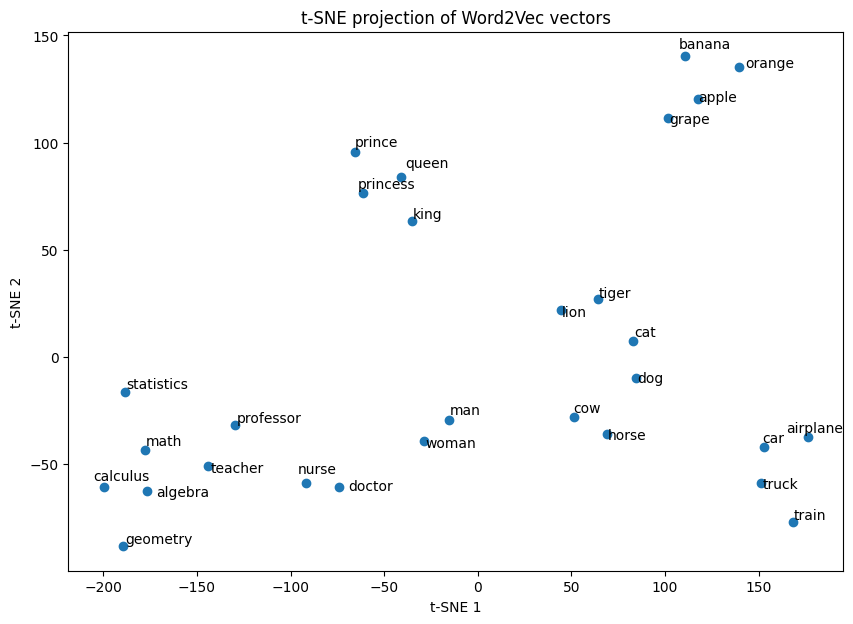

In [8]:
plt.figure(figsize=(10, 7))
plt.scatter(tsne_df["x"], tsne_df["y"])

texts = []
for _, row in tsne_df.iterrows():
    texts.append(plt.text(row["x"], row["y"], row["word"]))

adjust_text(texts)

plt.title("t-SNE projection of Word2Vec vectors")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

## 5. Reflection questions
### volunteered by github copilot

1. Which words are close together in the PCA plot?
2. Which words are close together in the t-SNE plot?
3. Are the plots telling the same story?
4. PCA tries to preserve large-scale variance. t-SNE tries to preserve local neighborhoods. Where do you see that difference?
5. Why might a 2D picture be misleading when the original vectors live in hundreds of dimensions?